# Baselines, Backtest und das LightGBM-Modell

Der Punkt ist die Methodik, nicht das Modell. Wir prognostizieren die Last 1–48 h voraus
und stellen eine einzige Frage: **Wie deutlich schlägt ein gelerntes Modell ehrliche
Baselines wirklich?**

- **Baselines zuerst.** Tagespersistenz (gleiche Stunde, ganzer Vortag) und saisonal-naiv
  (gleiche Stunde, Vorwoche). Wegen der starken Wochenstruktur der Last ist saisonal-naiv
  eine echte Messlatte — jedes Modell muss sich an ihr messen lassen, sonst ist der Aufwand
  nicht gerechtfertigt.
- **Direkte Multi-Horizont-Prognose.** Ein Modell je Horizont, das `y(t+h)` aus zum
  Zeitpunkt `t` bekannten Merkmalen schätzt. Gegenüber einer rekursiven Prognose (Schritt
  für Schritt vorhersagen und die Vorhersage wieder einspeisen) vermeidet das die
  Fehlerakkumulation und erlaubt pro Horizont passende Merkmale.
- **Warum LightGBM.** Gradient Boosting fängt die nichtlinearen Effekte (U-Form der
  Temperatur, Kalender × Last) und Interaktionen ohne viel Feature-Engineering ein,
  trainiert schnell und ist auf tabellarischen Lag-/Kalendermerkmalen robuster als ein LSTM
  bei dieser Datenmenge. Klassisches ARIMA/SARIMA skaliert schlecht auf mehrere
  Saisonalitäten und exogene Treiber zugleich.
- **Rollierender Backtest, kein Zufalls-Split.** Ein zufälliger Train/Test-Split würde
  Zukunft in die Vergangenheit lecken. Stattdessen: LightGBM monatlich auf einem
  rollierenden **Zwei-Jahres-Fenster** neu trainieren und auf dem Folgemonat bewerten; das
  Fenster begrenzt die Rechenkosten und lässt das Modell auf Regimewechsel reagieren. Die
  Baselines werden auf **exakt denselben** Zeitstempeln gemessen.
- **Leckagefreiheit.** Wetter geht als Temperatur zur Zielstunde ein (dokumentierter
  perfekter-Vorhersage-Proxy); Preis und Erzeugungsmix nur als Lags, die zum Zeitpunkt `t`
  bekannt sind.

Die Ergebnisse hier werden aus dem gecachten Backtest gelesen (`python -m src.evaluate`).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, features, model

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)

df = pd.read_parquet(config.DATASET_PARQUET)
metrics = pd.read_csv(config.PROCESSED / "backtest_metrics.csv")
preds = pd.read_parquet(config.BACKTEST_PARQUET)
metrics

,horizon,model,MAE,MAPE,RMSE,MAE_vs_seasonal_%
0,1,lightgbm,481.681038,0.916013,644.145418,81.5
1,1,naive,3952.942178,7.542790,5925.544171,-51.7
2,1,seasonal_naive,2605.084518,4.991930,4055.374784,0.0
3,6,lightgbm,1229.449130,2.342065,1643.577477,52.8
4,6,naive,3953.016264,7.543044,5925.559376,-51.8
5,6,seasonal_naive,2604.089732,4.989959,4053.958019,0.0
6,12,lightgbm,1397.538155,2.656628,1863.075781,46.3
7,12,naive,3951.296310,7.539987,5923.648610,-51.9
8,12,seasonal_naive,2601.873945,4.986084,4049.528447,0.0
9,24,lightgbm,1395.057079,2.665304,1875.840524,46.3


## Metriken gegen die Baselines, je Horizont

MAE und MAPE für jeden Horizont; die letzte Spalte ist die MAE-Reduktion von LightGBM
gegenüber saisonal-naiv. Schon hier zeigt sich das Muster: Der Vorsprung ist auf kurzen
Horizonten am größten und bleibt bis 48 h deutlich positiv.

In [2]:
view = metrics.pivot(index="horizon", columns="model", values="MAE").round(0)
view.columns = [f"MAE_{c}" for c in view.columns]
mape = metrics.pivot(index="horizon", columns="model", values="MAPE").round(2)
view["MAPE_lightgbm"] = mape["lightgbm"]
view["MAE_Reduktion_%"] = metrics[metrics.model == "lightgbm"].set_index("horizon")["MAE_vs_seasonal_%"]
view

,MAE_lightgbm,MAE_naive,MAE_seasonal_naive,MAPE_lightgbm,MAE_Reduktion_%
horizon,,,,,
1,482.0,3953.0,2605.0,0.92,81.5
6,1229.0,3953.0,2604.0,2.34,52.8
12,1398.0,3951.0,2602.0,2.66,46.3
24,1395.0,3950.0,2598.0,2.67,46.3
48,1665.0,6390.0,2595.0,3.17,35.8


## Fehler nach Horizont

Mit wachsendem Horizont behält das Modell seinen Vorsprung vor beiden Baselines. Während
die naiven Baselines nahezu horizontunabhängig sind (sie kopieren nur einen früheren Wert),
steigt der LightGBM-Fehler mit dem Horizont langsam an — bleibt aber überall klar darunter.
Diese Abbildung wird im README wiederverwendet.

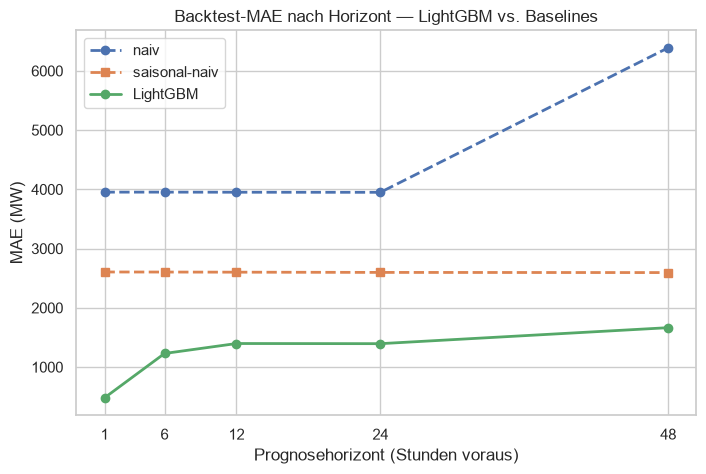

In [3]:
curve = metrics.pivot(index="horizon", columns="model", values="MAE")
labels = {"naive": "naiv", "seasonal_naive": "saisonal-naiv", "lightgbm": "LightGBM"}
fig, ax = plt.subplots(figsize=(8, 5))
for col, style in [("naive","o--"), ("seasonal_naive","s--"), ("lightgbm","o-")]:
    ax.plot(curve.index, curve[col], style, label=labels[col], lw=2)
ax.set(xlabel="Prognosehorizont (Stunden voraus)", ylabel="MAE (MW)",
       title="Backtest-MAE nach Horizont — LightGBM vs. Baselines")
ax.set_xticks(curve.index); ax.legend()
reports = config.ROOT / "reports"; reports.mkdir(exist_ok=True)
fig.savefig(reports / "error_by_horizon.png", dpi=110, bbox_inches="tight")
plt.show()

## Prognose vs. Ist

Ein Zwei-Wochen-Ausschnitt auf dem 24-h-Horizont: LightGBM trifft die täglichen Spitzen,
die die saisonal-naive Baseline systematisch verfehlt — besonders dort, wo eine Woche
zuvor ein anderes Muster herrschte (etwa rund um Feiertage oder Wetterwechsel).

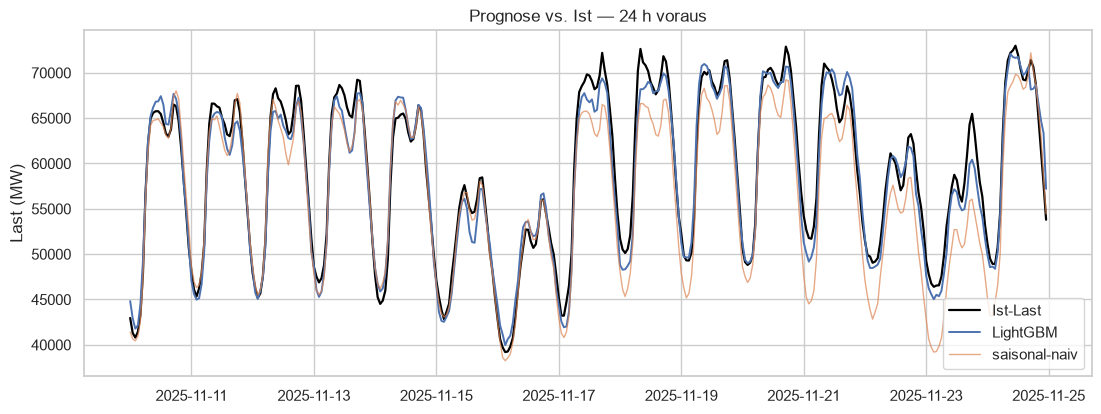

In [4]:
h = 24
hz = preds[preds.horizon == h].sort_index()
win = hz.loc["2025-11-10":"2025-11-24"]
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(win.index, win.y_true, label="Ist-Last", color="black", lw=1.6)
ax.plot(win.index, win.lightgbm, label="LightGBM", lw=1.4)
ax.plot(win.index, win.seasonal_naive, label="saisonal-naiv", lw=1.0, alpha=0.7)
ax.set(ylabel="Last (MW)", title=f"Prognose vs. Ist — {h} h voraus"); ax.legend()
plt.show()

## Wo gewinnt und wo verliert das Modell?

Die Residuen, aufgeschlüsselt nach Tagesstunde, Feiertagsflag und Temperatur. Die Fehler
konzentrieren sich auf die Morgen- und Abendrampen, auf Feiertage und auf Temperaturextreme
— also genau die schwierigen, unregelmäßigen Stunden. Das ist ein gutes Zeichen: Der
Restfehler steckt dort, wo die Last am wenigsten routinehaft ist, nicht in den gut
vorhersagbaren Normalstunden.

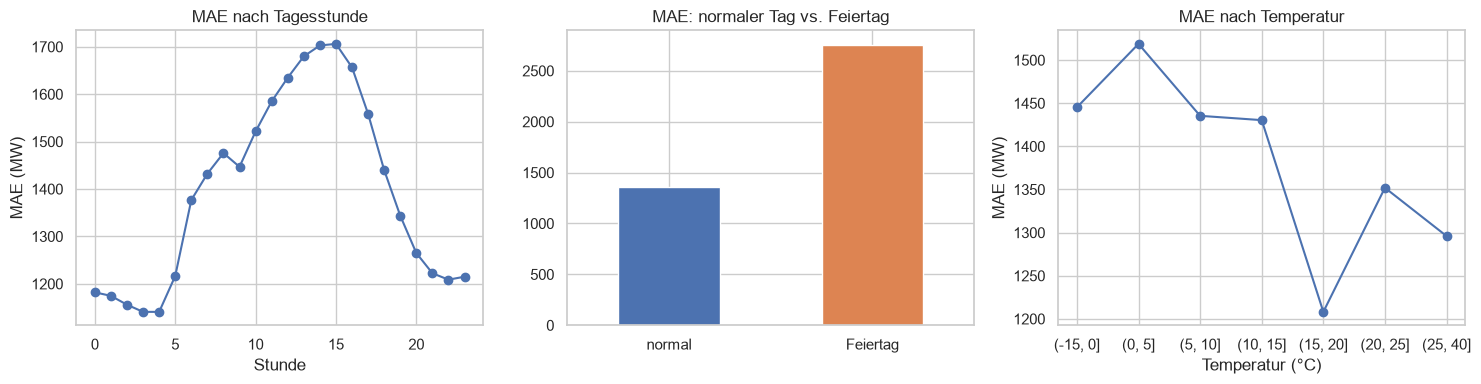

In [5]:
import holidays
h = 24
hz = preds[preds.horizon == h].copy()
hz["abs_err"] = (hz.y_true - hz.lightgbm).abs()
hz["hour"] = hz.index.hour
de = holidays.Germany()
hz["is_holiday"] = [d.date() in de for d in hz.index]
hz = hz.join(df["temp_DE"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
hz.groupby("hour")["abs_err"].mean().plot(ax=axes[0], marker="o")
axes[0].set(title="MAE nach Tagesstunde", xlabel="Stunde", ylabel="MAE (MW)")
hz.groupby("is_holiday")["abs_err"].mean().plot.bar(ax=axes[1], rot=0, color=["#4c72b0","#dd8452"])
axes[1].set(title="MAE: normaler Tag vs. Feiertag", xlabel="")
axes[1].set_xticklabels(["normal","Feiertag"])
tbin = pd.cut(hz["temp_DE"], bins=[-15,0,5,10,15,20,25,40])
hz.groupby(tbin, observed=True)["abs_err"].mean().plot(ax=axes[2], marker="o")
axes[2].set(title="MAE nach Temperatur", xlabel="Temperatur (°C)", ylabel="MAE (MW)")
plt.tight_layout(); plt.show()

## Was nutzt das Modell?

Feature-Importances eines LightGBM, der auf der vollen Historie für den 24-h-Horizont
trainiert wurde. Die jüngste Last und der Wochen-Lag (168 h) dominieren — sie tragen das
meiste Signal —, ergänzt um Temperatur und Kalender. Das deckt sich mit der EDA: Die
Autokorrelation bei 24 h/168 h und die U-Form der Temperatur schlagen direkt in die
wichtigsten Merkmale durch.

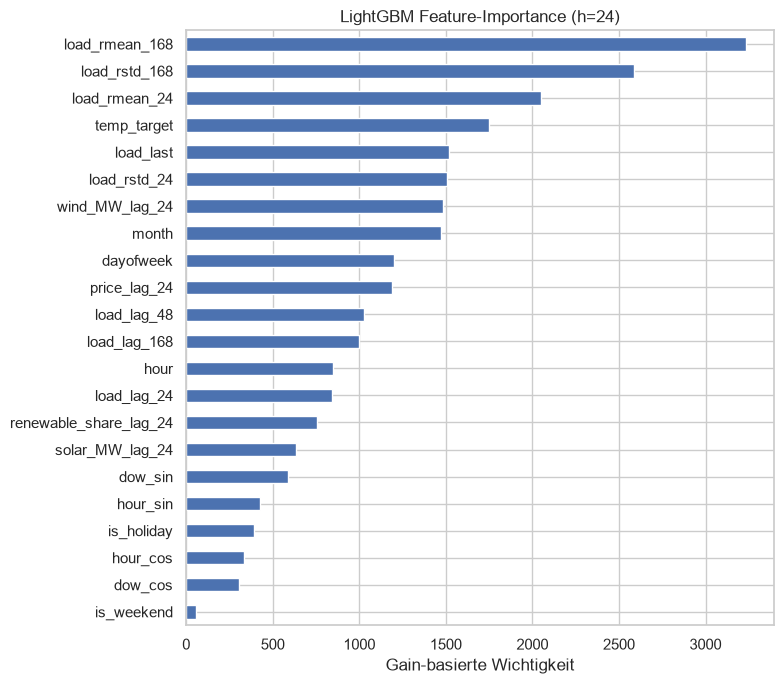

In [6]:
X, y = features.make_supervised(df, horizon=24)
fitted = model.train_lgbm(X, y)
imp = pd.Series(fitted.feature_importances_, index=X.columns).sort_values()
ax = imp.plot.barh(figsize=(8, 7))
ax.set(title="LightGBM Feature-Importance (h=24)", xlabel="Gain-basierte Wichtigkeit")
plt.tight_layout(); plt.show()

## Fazit

- LightGBM schlägt die starke saisonal-naive Baseline auf **jedem** Horizont, mit den
  größten Gewinnen auf kurzen Horizonten, wo die jüngste Last das meiste Signal trägt.
- Der verbleibende Fehler sitzt dort, wo er sitzen sollte: an den Tagesrampen, an
  Feiertagen und bei Temperaturextremen.
- Die ehrliche Evaluation (rollierend, baseline-relativ, leckage-getestet) ist das, was
  diese Zahlen vertrauenswürdig macht — siehe `tests/test_pipeline.py`.